# KMeans + HAC

Squashing dimensions for plotting (using PCA)...


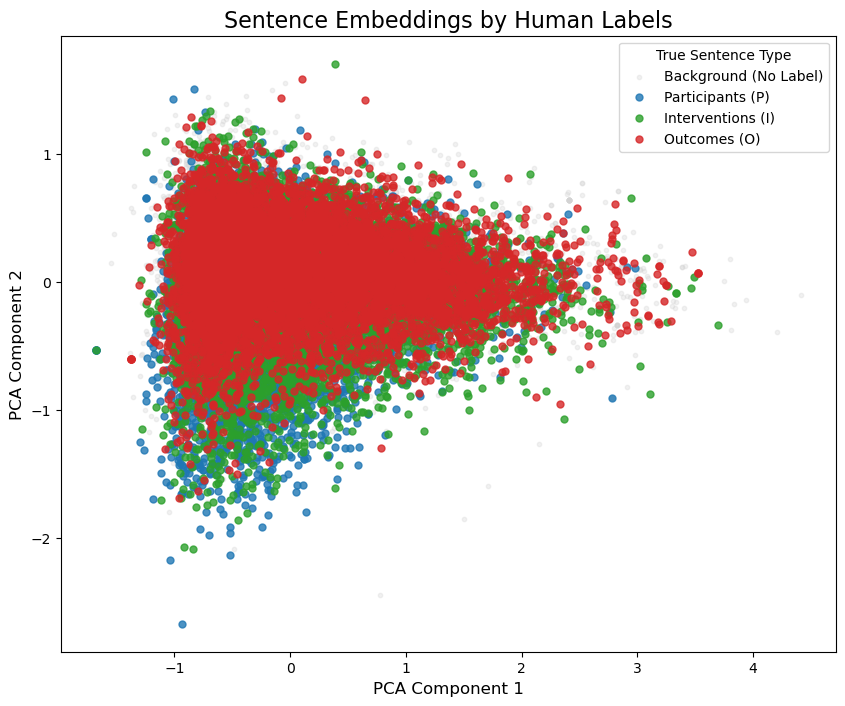

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

data = np.load("./data/ebm_nlp_2_00/processed/ebm_sentence_vectors.npz", allow_pickle=True)

X_train = data['X_train']

unified_labels = np.zeros(len(X_train)) # 0 = Background/None
unified_labels[data['y_o_train'] == 1] = 3 # 3 = Outcome
unified_labels[data['y_i_train'] == 1] = 2 # 2 = Intervention
unified_labels[data['y_p_train'] == 1] = 1 # 1 = Participant

def plot_true_labels(embeddings, true_labels):
    print("Squashing dimensions for plotting (using PCA)...")
    
    train_limit = min(30000, len(embeddings))
    X_subset = embeddings[:train_limit]
    y_subset = true_labels[:train_limit]
    
    pca = PCA(n_components=2)
    reduced_data = pca.fit_transform(X_subset)
    
    plt.figure(figsize=(10, 8))
    
    color_map = {0: 'lightgrey', 1: '#1f77b4', 2: '#2ca02c', 3: '#d62728'}
    label_names = {0: 'Background (No Label)', 1: 'Participants (P)', 2: 'Interventions (I)', 3: 'Outcomes (O)'}
    
    for label_val in [0, 1, 2, 3]:
        idx = (y_subset == label_val)
        
        plt.scatter(
            reduced_data[idx, 0], 
            reduced_data[idx, 1], 
            c=color_map[label_val], 
            label=label_names[label_val],
            alpha=0.3 if label_val == 0 else 0.8, 
            s=10 if label_val == 0 else 25
        )
        
    plt.title("Sentence Embeddings HAC", fontsize=16)
    plt.xlabel("PCA Component 1", fontsize=12)
    plt.ylabel("PCA Component 2", fontsize=12)
    
    plt.legend(title="True Sentence Type", fontsize=10)
    plt.show()

plot_true_labels(X_train, unified_labels)

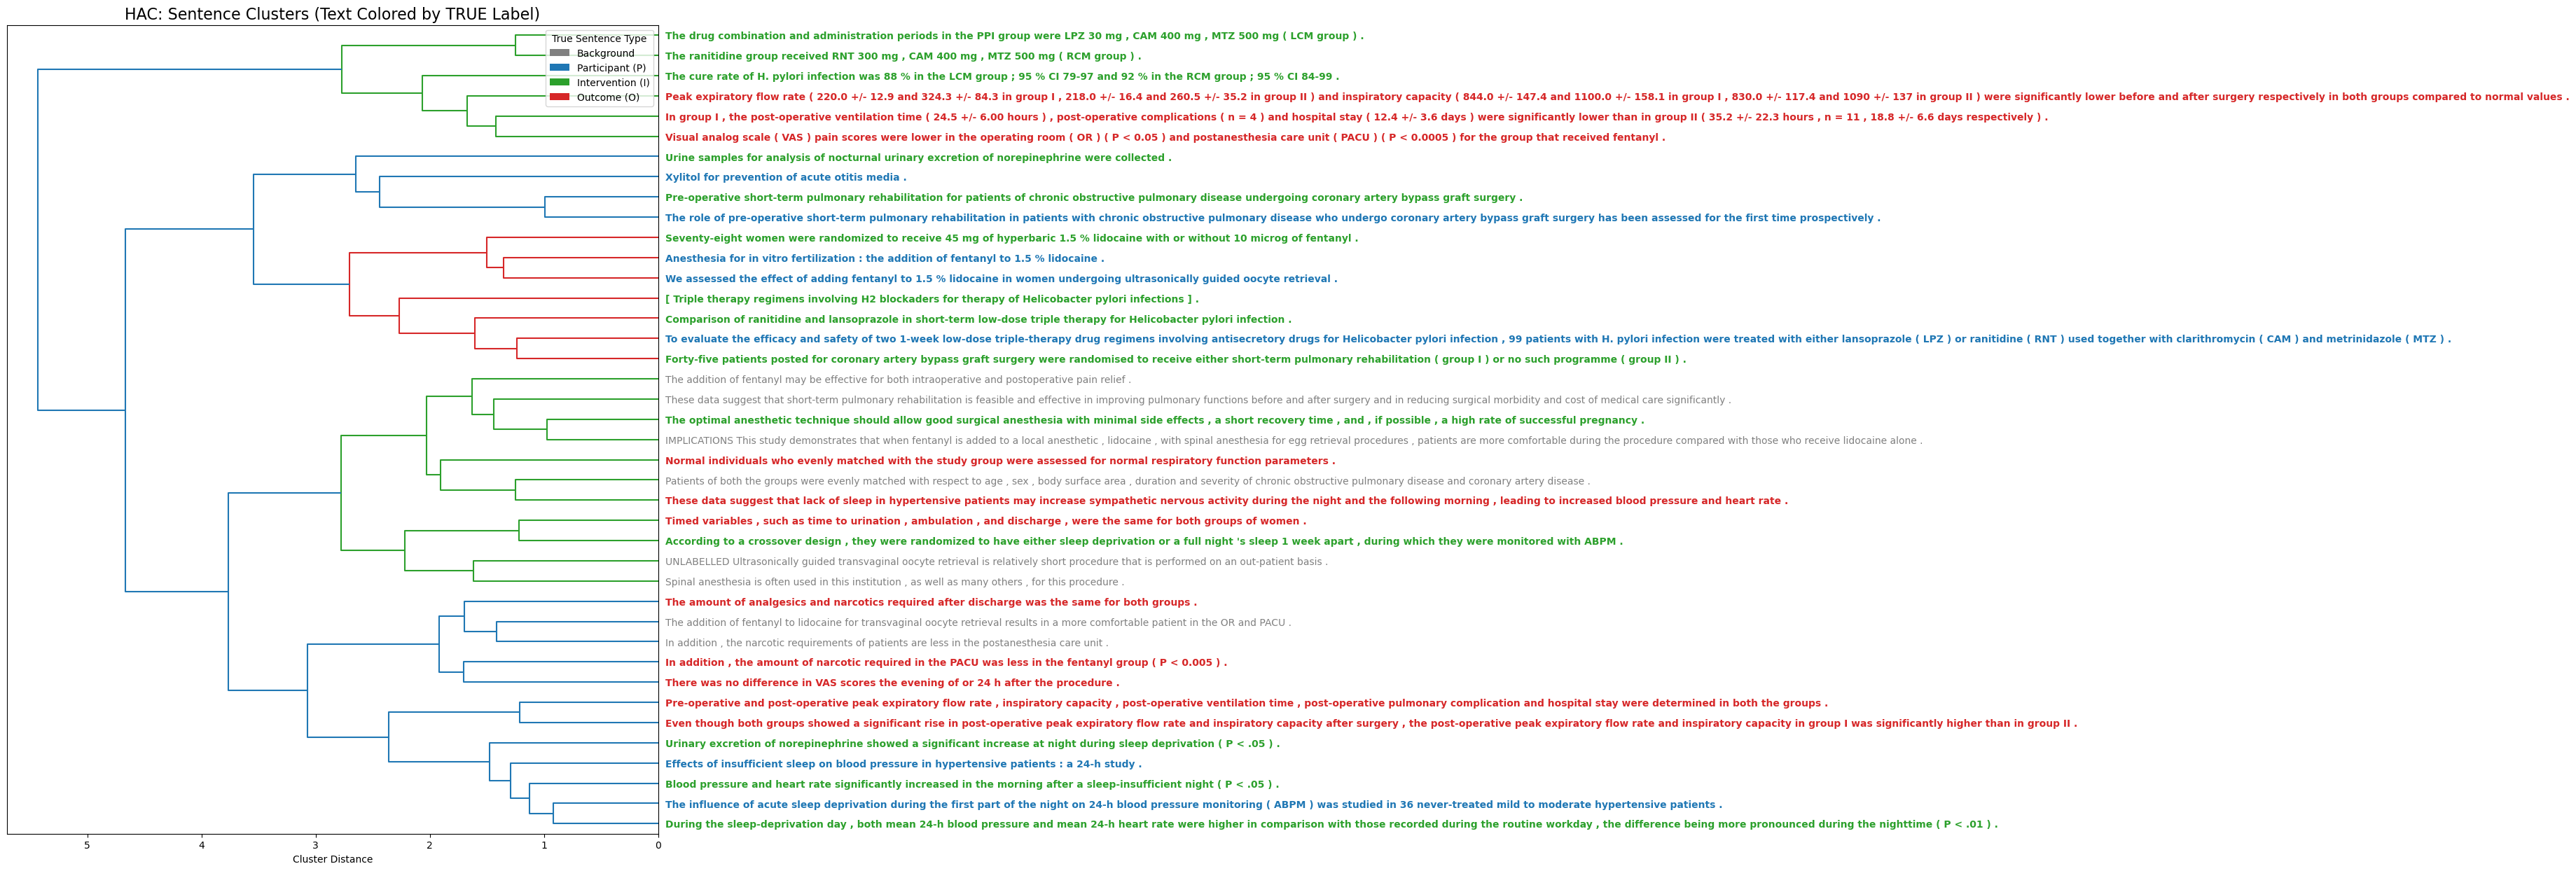

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.cluster.hierarchy import set_link_color_palette

data = np.load("./data/ebm_nlp_2_00/processed/ebm_sentence_vectors.npz", allow_pickle=True)

X_train = data['X_train']
X_test = data['X_test']
train_texts = data['texts_train']

unified_labels = np.zeros(len(X_train)) 
unified_labels[data['y_o_train'] == 1] = 3 
unified_labels[data['y_i_train'] == 1] = 2 
unified_labels[data['y_p_train'] == 1] = 1 

def plot_hac_colored_text(sample_size=40):
    set_link_color_palette(['#1f77b4', '#2ca02c', '#d62728']) 
    
    X_hac = X_train[:sample_size]
    labels_hac = train_texts[:sample_size]
    true_labels_hac = unified_labels[:sample_size]
    
    linked_sentences = linkage(X_hac, 'ward')
    
    plt.figure(figsize=(12, 15))
    
    ddata = dendrogram(
        linked_sentences,
        orientation='left',       
        labels=labels_hac,      
        distance_sort='descending',
        show_leaf_counts=True,
        leaf_font_size=10,
        color_threshold=3.5
    )
    
    color_map = {0: 'grey', 1: '#1f77b4', 2: '#2ca02c', 3: '#d62728'}
    
    ax = plt.gca()
    y_labels = ax.get_ymajorticklabels()
    
    for leaf_index, tick in zip(ddata['leaves'], y_labels):
        true_class = true_labels_hac[leaf_index]
        
        tick.set_color(color_map[true_class])
        
        if true_class != 0:
            tick.set_fontweight('bold')

    legend_elements = [
        Patch(facecolor='grey', label='Background'),
        Patch(facecolor='#1f77b4', label='Participant (P)'),
        Patch(facecolor='#2ca02c', label='Intervention (I)'),
        Patch(facecolor='#d62728', label='Outcome (O)')
    ]
    plt.legend(handles=legend_elements, loc='upper right', title="True Sentence Type", fontsize=10)

    plt.title("HAC: Sentence Clusters - Colour is True Labels", fontsize=16)
    plt.xlabel("Cluster Distance")
    plt.show()
    
    set_link_color_palette(None)

plot_hac_colored_text(sample_size=40)